In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## BÀI 3

In [3]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=7101c25cb1e521792dbf75f40b6bbad06d6759210be308234e6712d3a634021a
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


Using device: cuda
Loading datasets from Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!
Looking for data in: /content/drive/MyDrive/DATASET/PhoNER-COVID19/
Loaded 5027 sentences from /content/drive/MyDrive/DATASET/PhoNER-COVID19/train_syllable.json
Vocabulary size: 3967
Number of labels: 22
Labels: ['B-AGE', 'B-DATE', 'B-GENDER', 'B-JOB', 'B-LOCATION', 'B-NAME', 'B-ORGANIZATION', 'B-PATIENT_ID', 'B-SYMPTOM_AND_DISEASE', 'B-TRANSPORTATION', 'I-AGE', 'I-DATE', 'I-GENDER', 'I-JOB', 'I-LOCATION', 'I-NAME', 'I-ORGANIZATION', 'I-PATIENT_ID', 'I-SYMPTOM_AND_DISEASE', 'I-TRANSPORTATION', 'O']
Loaded 2000 sentences from /content/drive/MyDrive/DATASET/PhoNER-COVID19/dev_syllable.json
Loaded 3000 sentences from /content/drive/MyDrive/DATASET/PhoNER-COVID19/test_syllable.json

Model architecture:
EncoderDecoderNER(
  (encoder): EncoderLSTM(
    (embedding): Embedding

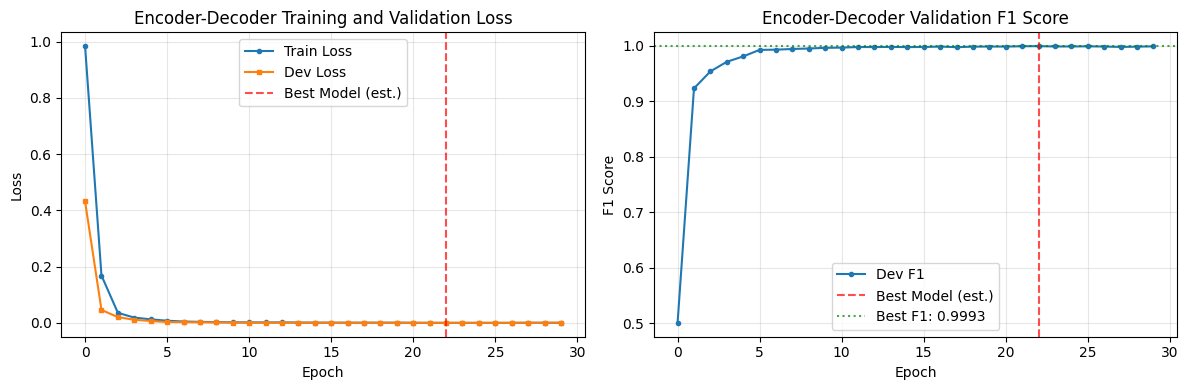

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import json
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from seqeval.metrics import f1_score as seq_f1_score
from seqeval.metrics import classification_report as seq_classification_report

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


class EarlyStopping:
    """Early stopping to stop training when validation F1 doesn't improve"""
    def __init__(self, patience=5, min_delta=0.0001, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_f1 = 0

    def __call__(self, val_f1, model, path='best_encoder_decoder_ner.pt'):
        score = val_f1

        if self.best_score is None:
            self.best_score = score
            self.best_f1 = val_f1
            self.save_checkpoint(val_f1, model, path)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'  EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_f1 = val_f1
            self.save_checkpoint(val_f1, model, path)
            self.counter = 0

    def save_checkpoint(self, val_f1, model, path):
        if self.verbose:
            print(f'  → Validation F1 improved ({self.best_f1:.4f} --> {val_f1:.4f}). Saving model...')
        torch.save(model.state_dict(), path)
        self.best_f1 = val_f1


class Vocabulary:
    """Build vocabulary from training data"""
    def __init__(self, max_vocab_size=20000):
        self.word2idx = {"<PAD>": 0, "<UNK>": 1}
        self.idx2word = {0: "<PAD>", 1: "<UNK>"}
        self.max_vocab_size = max_vocab_size

    def build_vocab(self, sentences):
        """Build vocabulary from list of tokenized sentences"""
        word_freq = Counter()
        for sentence in sentences:
            word_freq.update(sentence)

        most_common = word_freq.most_common(self.max_vocab_size - 2)

        for idx, (word, _) in enumerate(most_common, start=2):
            self.word2idx[word] = idx
            self.idx2word[idx] = word

        print(f"Vocabulary size: {len(self.word2idx)}")

    def encode(self, sentence):
        """Convert sentence to list of indices"""
        return [self.word2idx.get(word, 1) for word in sentence]


class LabelEncoder:
    """Encode NER labels"""
    def __init__(self):
        self.label2idx = {"<PAD>": 0}
        self.idx2label = {0: "<PAD>"}

    def build_labels(self, labels_list):
        """Build label encoding from list of label sequences"""
        unique_labels = set()
        for labels in labels_list:
            unique_labels.update(labels)

        for idx, label in enumerate(sorted(unique_labels), start=1):
            self.label2idx[label] = idx
            self.idx2label[idx] = label

        print(f"Number of labels: {len(self.label2idx)}")
        print(f"Labels: {sorted(unique_labels)}")

    def encode(self, labels):
        """Convert labels to indices"""
        # If a label not in label2idx (shouldn't happen for dev/test if using train label encoder),
        # map to PAD (0) or raise; here we map to 0 to avoid crash.
        return [self.label2idx.get(label, 0) for label in labels]

    def decode(self, indices):
        """Convert indices back to labels"""
        return [self.idx2label.get(idx, "<PAD>") for idx in indices if idx != 0]


def load_json_or_jsonl(file_path):
    """
    Load either a JSON list file or a JSON Lines file.
    Returns a Python list of objects (dicts).
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read().strip()
        if not text:
            return []
        # If starts with '[' -> whole-file JSON list
        if text.startswith('['):
            try:
                return json.loads(text)
            except json.JSONDecodeError:
                # fallback to line-by-line
                pass
        # Try to parse as JSONL (one JSON object per line)
        objs = []
        with open(file_path, 'r', encoding='utf-8') as ff:
            for line_no, line in enumerate(ff, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    objs.append(json.loads(line))
                except json.JSONDecodeError as e:
                    # give helpful message and re-raise
                    raise json.JSONDecodeError(f"Error parsing JSON at line {line_no} in {file_path}: {e.msg}", e.doc, e.pos)
        return objs


class PhoNERDataset(Dataset):
    """Dataset class for PhoNER (JSON or JSONL format)"""
    def __init__(self, file_path, vocab=None, label_encoder=None, is_train=False):
        # Load JSON/JSONL file
        data = load_json_or_jsonl(file_path)

        self.sentences = []
        self.labels = []

        # Parse various JSON formats commonly seen
        for item in data:
            # skip non-dicts or empty
            if not isinstance(item, dict):
                continue
            # prefer common key combos: 'words'/'tags', 'words'/'ner_tags', 'tokens'/'tags'
            if 'words' in item and 'tags' in item:
                self.sentences.append(item['words'])
                self.labels.append(item['tags'])
            elif 'words' in item and 'ner_tags' in item:
                self.sentences.append(item['words'])
                self.labels.append(item['ner_tags'])
            elif 'tokens' in item and 'tags' in item:
                self.sentences.append(item['tokens'])
                self.labels.append(item['tags'])
            elif 'tokens' in item and 'ner_tags' in item:
                self.sentences.append(item['tokens'])
                self.labels.append(item['ner_tags'])
            else:
                # if format unknown, try to find any list-like fields
                # this is a fallback and conservative
                possible_words = None
                possible_tags = None
                for k, v in item.items():
                    if isinstance(v, list) and all(isinstance(x, str) for x in v) and possible_words is None:
                        possible_words = v
                    elif isinstance(v, list) and all(isinstance(x, str) for x in v) and possible_tags is None:
                        possible_tags = v
                if possible_words is not None and possible_tags is not None and len(possible_words) == len(possible_tags):
                    self.sentences.append(possible_words)
                    self.labels.append(possible_tags)
                else:
                    # skip entries we can't parse
                    continue

        print(f"Loaded {len(self.sentences)} sentences from {file_path}")

        # Build vocabulary and label encoder on training set
        if is_train:
            self.vocab = Vocabulary()
            self.vocab.build_vocab(self.sentences)

            self.label_encoder = LabelEncoder()
            self.label_encoder.build_labels(self.labels)
        else:
            if vocab is None or label_encoder is None:
                raise ValueError("vocab and label_encoder must be provided for non-training datasets")
            self.vocab = vocab
            self.label_encoder = label_encoder

        # Encode sentences and labels
        self.encoded_sentences = [torch.tensor(self.vocab.encode(sent), dtype=torch.long) for sent in self.sentences]
        self.encoded_labels = [torch.tensor(self.label_encoder.encode(labels), dtype=torch.long) for labels in self.labels]

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        return (
            self.encoded_sentences[idx],
            self.encoded_labels[idx],
            self.sentences[idx],
            self.labels[idx]
        )


def collate_fn(batch):
    """Custom collate function to pad sequences"""
    sentences, labels, orig_words, orig_labels = zip(*batch)

    lengths = torch.tensor([s.size(0) for s in sentences], dtype=torch.long)
    sentences_padded = pad_sequence(sentences, batch_first=True, padding_value=0)
    labels_padded = pad_sequence(labels, batch_first=True, padding_value=0)

    return sentences_padded, labels_padded, lengths, orig_words, orig_labels


class EncoderLSTM(nn.Module):
    """5-layer LSTM Encoder"""
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout=0.5):
        super(EncoderLSTM, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.hidden_size = hidden_size

        # 5 LSTM layers
        self.lstm1 = nn.LSTM(embedding_dim, hidden_size, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.lstm3 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.lstm4 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.lstm5 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, lengths):
        embedded = self.embedding(x)

        out, _ = self.lstm1(embedded)
        out = self.dropout(out)

        out, _ = self.lstm2(out)
        out = self.dropout(out)

        out, _ = self.lstm3(out)
        out = self.dropout(out)

        out, _ = self.lstm4(out)
        out = self.dropout(out)

        out, (hidden, cell) = self.lstm5(out)

        return out, (hidden, cell)


class DecoderLSTM(nn.Module):
    """5-layer LSTM Decoder"""
    def __init__(self, num_labels, embedding_dim, hidden_size, dropout=0.5):
        super(DecoderLSTM, self).__init__()

        self.embedding = nn.Embedding(num_labels, embedding_dim, padding_idx=0)
        self.hidden_size = hidden_size

        # 5 LSTM layers
        # note: first LSTM input dim = encoder_outputs dim (hidden_size*2) + embedding dim
        self.lstm1 = nn.LSTM(hidden_size * 2 + embedding_dim, hidden_size,
                            batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.lstm3 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.lstm4 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.lstm5 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_labels)

    def forward(self, encoder_outputs, labels):
        batch_size, seq_len = labels.size()

        # Teacher forcing: use previous label to predict next
        decoder_input = torch.zeros(batch_size, 1, dtype=torch.long, device=labels.device)
        decoder_input = torch.cat([decoder_input, labels[:, :-1]], dim=1)

        embedded = self.embedding(decoder_input)
        decoder_input_combined = torch.cat([encoder_outputs, embedded], dim=-1)

        out, _ = self.lstm1(decoder_input_combined)
        out = self.dropout(out)

        out, _ = self.lstm2(out)
        out = self.dropout(out)

        out, _ = self.lstm3(out)
        out = self.dropout(out)

        out, _ = self.lstm4(out)
        out = self.dropout(out)

        out, _ = self.lstm5(out)
        out = self.dropout(out)

        out = self.fc(out)
        return out


class EncoderDecoderNER(nn.Module):
    """5-layer Encoder + 5-layer Decoder LSTM for NER"""
    def __init__(self, vocab_size, num_labels, embedding_dim, hidden_size, dropout=0.5):
        super(EncoderDecoderNER, self).__init__()

        self.encoder = EncoderLSTM(vocab_size, embedding_dim, hidden_size, dropout)
        self.decoder = DecoderLSTM(num_labels, embedding_dim, hidden_size, dropout)

    def forward(self, sentences, labels, lengths):
        encoder_outputs, (hidden, cell) = self.encoder(sentences, lengths)
        decoder_outputs = self.decoder(encoder_outputs, labels)
        return decoder_outputs


def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0

    for sentences, labels, lengths, _, _ in dataloader:
        sentences = sentences.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device)

        optimizer.zero_grad()
        outputs = model(sentences, labels, lengths)

        outputs = outputs.view(-1, outputs.size(-1))
        labels_flat = labels.view(-1)

        loss = criterion(outputs, labels_flat)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate(model, dataloader, criterion, device, label_encoder):
    """Evaluate the model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for sentences, labels, lengths, orig_words, orig_labels in dataloader:
            sentences = sentences.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)

            outputs = model(sentences, labels, lengths)

            outputs_flat = outputs.view(-1, outputs.size(-1))
            labels_flat = labels.view(-1)
            loss = criterion(outputs_flat, labels_flat)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=-1)

            for i in range(len(sentences)):
                length = lengths[i].item()
                pred_labels = [label_encoder.idx2label.get(idx.item(), "<PAD>") for idx in preds[i][:length]]
                true_labels = list(orig_labels[i])

                all_preds.append(pred_labels)
                all_labels.append(true_labels)

    avg_loss = total_loss / len(dataloader)
    f1 = seq_f1_score(all_labels, all_preds) if len(all_preds) > 0 else 0.0

    return avg_loss, f1, all_preds, all_labels


def main():
    # Hyperparameters
    EMBEDDING_DIM = 128
    HIDDEN_SIZE = 256
    BATCH_SIZE = 32
    NUM_EPOCHS = 50
    LEARNING_RATE = 0.001
    PATIENCE = 7
    MIN_DELTA = 0.0001

    # Load datasets from Google Drive
    print("Loading datasets from Google Drive...")

    try:
        from google.colab import drive
        drive.mount('/content/drive')
        base_path = '/content/drive/MyDrive/DATASET/PhoNER-COVID19/'
        print(f"Google Drive mounted successfully!")
        print(f"Looking for data in: {base_path}")
    except:
        print("Not running in Google Colab, using local files...")
        base_path = './'

    try:
        train_dataset = PhoNERDataset(f'{base_path}train_syllable.json', is_train=True)
        dev_dataset = PhoNERDataset(f'{base_path}dev_syllable.json',
                                    vocab=train_dataset.vocab,
                                    label_encoder=train_dataset.label_encoder)
        test_dataset = PhoNERDataset(f'{base_path}test_syllable.json',
                                     vocab=train_dataset.vocab,
                                     label_encoder=train_dataset.label_encoder)
    except FileNotFoundError as e:
        print(f"\nError: {e}")
        print("\nPlease download PhoNER_COVID19 dataset from:")
        print("https://github.com/VinAIResearch/PhoNER_COVID19")
        print("\nExpected files: train_syllable.json, dev_syllable.json, test_syllable.json")
        return
    except json.JSONDecodeError as e:
        print(f"\nJSON parsing error: {e}")
        return

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              shuffle=True, collate_fn=collate_fn)
    dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE,
                            shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             shuffle=False, collate_fn=collate_fn)

    # Initialize model
    vocab_size = len(train_dataset.vocab.word2idx)
    num_labels = len(train_dataset.label_encoder.label2idx)

    model = EncoderDecoderNER(vocab_size, num_labels, EMBEDDING_DIM,
                              HIDDEN_SIZE).to(device)
    print(f"\nModel architecture:\n{model}")
    print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Early stopping
    early_stopping = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA, verbose=True)

    # Training loop
    train_losses, dev_losses, dev_f1s = [], [], []

    print(f"\nStarting training with early stopping (patience={PATIENCE})...")
    for epoch in range(NUM_EPOCHS):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        dev_loss, dev_f1, _, _ = evaluate(model, dev_loader, criterion, device,
                                          train_dataset.label_encoder)

        train_losses.append(train_loss)
        dev_losses.append(dev_loss)
        dev_f1s.append(dev_f1)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Dev Loss: {dev_loss:.4f}, Dev F1: {dev_f1:.4f}")

        early_stopping(dev_f1, model)

        if early_stopping.early_stop:
            print(f"\n{'='*50}")
            print(f"Early stopping triggered at epoch {epoch+1}")
            print(f"Best validation F1: {early_stopping.best_f1:.4f}")
            print(f"{'='*50}\n")
            break

    # Load best model and evaluate on test set
    print("Loading best model for test evaluation...")
    model.load_state_dict(torch.load('best_encoder_decoder_ner.pt', map_location=device))
    test_loss, test_f1, test_preds, test_labels = evaluate(
        model, test_loader, criterion, device, train_dataset.label_encoder)

    print(f"\n{'='*50}")
    print(f"Final Test Results:")
    print(f"  Test Loss: {test_loss:.4f}")
    print(f"  Test F1: {test_f1:.4f}")
    print(f"  Best Dev F1: {early_stopping.best_f1:.4f}")
    print(f"  Total Epochs Trained: {len(train_losses)}")
    print(f"{'='*50}")

    print("\nDetailed Classification Report:")
    print(seq_classification_report(test_labels, test_preds))

    # Plot training curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o', markersize=3)
    plt.plot(dev_losses, label='Dev Loss', marker='s', markersize=3)
    # mark best model epoch if early stopping triggered; else mark last-possible
    best_epoch_marker = max(0, len(dev_f1s) - PATIENCE - 1)
    plt.axvline(x=best_epoch_marker, color='r', linestyle='--',
                label='Best Model (est.)', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Encoder-Decoder Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(dev_f1s, label='Dev F1', marker='o', markersize=3)
    plt.axvline(x=best_epoch_marker, color='r', linestyle='--',
                label='Best Model (est.)', alpha=0.7)
    plt.axhline(y=early_stopping.best_f1, color='g', linestyle=':',
                label=f'Best F1: {early_stopping.best_f1:.4f}', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.title('Encoder-Decoder Validation F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('encoder_decoder_training_curves.png', dpi=300, bbox_inches='tight')
    print("\nTraining curves saved as 'encoder_decoder_training_curves.png'")


if __name__ == "__main__":
    main()

Using device: cuda
Loading datasets from Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!
Looking for data in: /content/drive/MyDrive/DATASET/PhoNER-COVID19/
Loaded 5027 sentences from /content/drive/MyDrive/DATASET/PhoNER-COVID19/train_syllable.json
Vocabulary size: 3967
Number of labels: 22
Labels: ['B-AGE', 'B-DATE', 'B-GENDER', 'B-JOB', 'B-LOCATION', 'B-NAME', 'B-ORGANIZATION', 'B-PATIENT_ID', 'B-SYMPTOM_AND_DISEASE', 'B-TRANSPORTATION', 'I-AGE', 'I-DATE', 'I-GENDER', 'I-JOB', 'I-LOCATION', 'I-NAME', 'I-ORGANIZATION', 'I-PATIENT_ID', 'I-SYMPTOM_AND_DISEASE', 'I-TRANSPORTATION', 'O']
Loaded 2000 sentences from /content/drive/MyDrive/DATASET/PhoNER-COVID19/dev_syllable.json
Loaded 3000 sentences from /content/drive/MyDrive/DATASET/PhoNER-COVID19/test_syllable.json

Model architecture:
EncoderDecoderNER(
  (encoder): EncoderLSTM(
    (embedding): Embedding

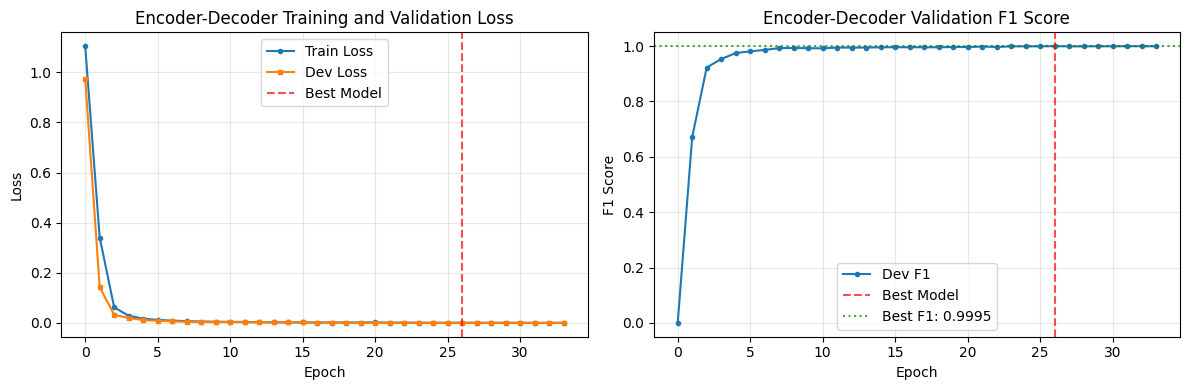

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import json
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from seqeval.metrics import f1_score as seq_f1_score
from seqeval.metrics import classification_report as seq_classification_report

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


class EarlyStopping:
    """Early stopping to stop training when validation F1 doesn't improve"""
    def __init__(self, patience=5, min_delta=0.0001, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_f1 = 0

    def __call__(self, val_f1, model, path='best_encoder_decoder_ner.pt'):
        score = val_f1

        if self.best_score is None:
            self.best_score = score
            self.best_f1 = val_f1
            self.save_checkpoint(val_f1, model, path)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'  EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_f1 = val_f1
            self.save_checkpoint(val_f1, model, path)
            self.counter = 0

    def save_checkpoint(self, val_f1, model, path):
        if self.verbose:
            print(f'  → Validation F1 improved ({self.best_f1:.4f} --> {val_f1:.4f}). Saving model...')
        torch.save(model.state_dict(), path)
        self.best_f1 = val_f1


class Vocabulary:
    """Build vocabulary from training data"""
    def __init__(self, max_vocab_size=20000):
        self.word2idx = {"<PAD>": 0, "<UNK>": 1}
        self.idx2word = {0: "<PAD>", 1: "<UNK>"}
        self.max_vocab_size = max_vocab_size

    def build_vocab(self, sentences):
        """Build vocabulary from list of tokenized sentences"""
        word_freq = Counter()
        for sentence in sentences:
            word_freq.update(sentence)

        most_common = word_freq.most_common(self.max_vocab_size - 2)

        for idx, (word, _) in enumerate(most_common, start=2):
            self.word2idx[word] = idx
            self.idx2word[idx] = word

        print(f"Vocabulary size: {len(self.word2idx)}")

    def encode(self, sentence):
        """Convert sentence to list of indices"""
        return [self.word2idx.get(word, 1) for word in sentence]


class LabelEncoder:
    """Encode NER labels"""
    def __init__(self):
        self.label2idx = {"<PAD>": 0}
        self.idx2label = {0: "<PAD>"}

    def build_labels(self, labels_list):
        """Build label encoding from list of label sequences"""
        unique_labels = set()
        for labels in labels_list:
            unique_labels.update(labels)

        for idx, label in enumerate(sorted(unique_labels), start=1):
            self.label2idx[label] = idx
            self.idx2label[idx] = label

        print(f"Number of labels: {len(self.label2idx)}")
        print(f"Labels: {sorted(unique_labels)}")

    def encode(self, labels):
        """Convert labels to indices"""
        return [self.label2idx[label] for label in labels]

    def decode(self, indices):
        """Convert indices back to labels"""
        return [self.idx2label[idx] for idx in indices if idx != 0]

def load_json_or_jsonl(file_path):
    """
    Load either a JSON list file or a JSON Lines file.
    Returns a Python list of objects (dicts).
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read().strip()
        if not text:
            return []
        # If starts with '[' -> whole-file JSON list
        if text.startswith('['):
            try:
                return json.loads(text)
            except json.JSONDecodeError:
                # fallback to line-by-line
                pass
        # Try to parse as JSONL (one JSON object per line)
        objs = []
        with open(file_path, 'r', encoding='utf-8') as ff:
            for line_no, line in enumerate(ff, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    objs.append(json.loads(line))
                except json.JSONDecodeError as e:
                    # give helpful message and re-raise
                    raise json.JSONDecodeError(f"Error parsing JSON at line {line_no} in {file_path}: {e.msg}", e.doc, e.pos)
        return objs


class PhoNERDataset(Dataset):
    """Dataset class for PhoNER (JSON or JSONL format)"""
    def __init__(self, file_path, vocab=None, label_encoder=None, is_train=False):
        # Load JSON/JSONL file
        data = load_json_or_jsonl(file_path)

        self.sentences = []
        self.labels = []

        # Parse various JSON formats commonly seen
        for item in data:
            # skip non-dicts or empty
            if not isinstance(item, dict):
                continue
            # prefer common key combos: 'words'/'tags', 'words'/'ner_tags', 'tokens'/'tags'
            if 'words' in item and 'tags' in item:
                self.sentences.append(item['words'])
                self.labels.append(item['tags'])
            elif 'words' in item and 'ner_tags' in item:
                self.sentences.append(item['words'])
                self.labels.append(item['ner_tags'])
            elif 'tokens' in item and 'tags' in item:
                self.sentences.append(item['tokens'])
                self.labels.append(item['tags'])
            elif 'tokens' in item and 'ner_tags' in item:
                self.sentences.append(item['tokens'])
                self.labels.append(item['ner_tags'])
            else:
                # if format unknown, try to find any list-like fields
                # this is a fallback and conservative
                possible_words = None
                possible_tags = None
                for k, v in item.items():
                    if isinstance(v, list) and all(isinstance(x, str) for x in v) and possible_words is None:
                        possible_words = v
                    elif isinstance(v, list) and all(isinstance(x, str) for x in v) and possible_tags is None:
                        possible_tags = v
                if possible_words is not None and possible_tags is not None and len(possible_words) == len(possible_tags):
                    self.sentences.append(possible_words)
                    self.labels.append(possible_tags)
                else:
                    # skip entries we can't parse
                    continue

        print(f"Loaded {len(self.sentences)} sentences from {file_path}")

        # Build vocabulary and label encoder on training set
        if is_train:
            self.vocab = Vocabulary()
            self.vocab.build_vocab(self.sentences)

            self.label_encoder = LabelEncoder()
            self.label_encoder.build_labels(self.labels)
        else:
            if vocab is None or label_encoder is None:
                raise ValueError("vocab and label_encoder must be provided for non-training datasets")
            self.vocab = vocab
            self.label_encoder = label_encoder

        # Encode sentences and labels
        self.encoded_sentences = [torch.tensor(self.vocab.encode(sent), dtype=torch.long) for sent in self.sentences]
        self.encoded_labels = [torch.tensor(self.label_encoder.encode(labels), dtype=torch.long) for labels in self.labels]

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        return (
            self.encoded_sentences[idx],
            self.encoded_labels[idx],
            self.sentences[idx],
            self.labels[idx]
        )


def collate_fn(batch):
    """Custom collate function to pad sequences"""
    sentences, labels, orig_words, orig_labels = zip(*batch)

    lengths = torch.tensor([len(s) for s in sentences])
    sentences_padded = pad_sequence(sentences, batch_first=True, padding_value=0)
    labels_padded = pad_sequence(labels, batch_first=True, padding_value=0)

    return sentences_padded, labels_padded, lengths, orig_words, orig_labels


class EncoderLSTM(nn.Module):
    """5-layer LSTM Encoder with Dropout"""
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout=0.5):
        super(EncoderLSTM, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding_dropout = nn.Dropout(dropout * 0.5)
        self.hidden_size = hidden_size

        # 5 LSTM layers with dropout parameter
        self.lstm1 = nn.LSTM(embedding_dim, hidden_size, batch_first=True,
                            bidirectional=True)
        self.lstm2 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True,
                            bidirectional=True)
        self.lstm3 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True,
                            bidirectional=True)
        self.lstm4 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True,
                            bidirectional=True)
        self.lstm5 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True,
                            bidirectional=True)

        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_size * 2)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        embedded = self.embedding_dropout(embedded)

        out, _ = self.lstm1(embedded)
        out = self.dropout(out)

        out, _ = self.lstm2(out)
        out = self.dropout(out)

        out, _ = self.lstm3(out)
        out = self.dropout(out)

        out, _ = self.lstm4(out)
        out = self.dropout(out)

        out, (hidden, cell) = self.lstm5(out)

        out = self.layer_norm(out)

        return out, (hidden, cell)


class DecoderLSTM(nn.Module):
    """5-layer LSTM Decoder"""
    def __init__(self, num_labels, embedding_dim, hidden_size, dropout=0.6):
        super(DecoderLSTM, self).__init__()

        self.embedding = nn.Embedding(num_labels, embedding_dim, padding_idx=0)
        self.hidden_size = hidden_size

        # 5 LSTM layers
        self.lstm1 = nn.LSTM(hidden_size * 2 + embedding_dim, hidden_size,
                            batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.lstm3 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.lstm4 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.lstm5 = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_labels)

    def forward(self, encoder_outputs, labels):
        batch_size, seq_len = labels.size()

        # Teacher forcing: use previous label to predict next
        decoder_input = torch.zeros(batch_size, 1, dtype=torch.long, device=labels.device)
        decoder_input = torch.cat([decoder_input, labels[:, :-1]], dim=1)

        embedded = self.embedding(decoder_input)
        decoder_input_combined = torch.cat([encoder_outputs, embedded], dim=-1)

        out, _ = self.lstm1(decoder_input_combined)
        out = self.dropout(out)

        out, _ = self.lstm2(out)
        out = self.dropout(out)

        out, _ = self.lstm3(out)
        out = self.dropout(out)

        out, _ = self.lstm4(out)
        out = self.dropout(out)

        out, _ = self.lstm5(out)
        out = self.dropout(out)

        out = self.fc(out)
        return out


class EncoderDecoderNER(nn.Module):
    """5-layer Encoder + 5-layer Decoder LSTM for NER"""
    def __init__(self, vocab_size, num_labels, embedding_dim, hidden_size, dropout=0.5):
        super(EncoderDecoderNER, self).__init__()

        self.encoder = EncoderLSTM(vocab_size, embedding_dim, hidden_size, dropout)
        self.decoder = DecoderLSTM(num_labels, embedding_dim, hidden_size, dropout)

    def forward(self, sentences, labels, lengths):
        encoder_outputs, (hidden, cell) = self.encoder(sentences, lengths)
        decoder_outputs = self.decoder(encoder_outputs, labels)
        return decoder_outputs


def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0

    for sentences, labels, lengths, _, _ in dataloader:
        sentences = sentences.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device)

        optimizer.zero_grad()
        outputs = model(sentences, labels, lengths)

        outputs = outputs.view(-1, outputs.size(-1))
        labels_flat = labels.view(-1)

        loss = criterion(outputs, labels_flat)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate(model, dataloader, criterion, device, label_encoder):
    """Evaluate the model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for sentences, labels, lengths, orig_words, orig_labels in dataloader:
            sentences = sentences.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)

            outputs = model(sentences, labels, lengths)

            outputs_flat = outputs.view(-1, outputs.size(-1))
            labels_flat = labels.view(-1)
            loss = criterion(outputs_flat, labels_flat)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=-1)

            for i in range(len(sentences)):
                length = lengths[i].item()
                pred_labels = [label_encoder.idx2label[idx.item()]
                              for idx in preds[i][:length]]
                true_labels = list(orig_labels[i])

                all_preds.append(pred_labels)
                all_labels.append(true_labels)

    avg_loss = total_loss / len(dataloader)
    f1 = seq_f1_score(all_labels, all_preds)

    return avg_loss, f1, all_preds, all_labels


def main():
    # Hyperparameters
    EMBEDDING_DIM = 128
    HIDDEN_SIZE = 256
    BATCH_SIZE = 32
    NUM_EPOCHS = 50
    LEARNING_RATE = 5e-4
    PATIENCE = 7
    MIN_DELTA = 0.0001
    WEIGHT_DECAY = 1e-4
    DROPOUT_RATE = 0.75

# Load datasets from Google Drive
    print("Loading datasets from Google Drive...")

    try:
        from google.colab import drive
        drive.mount('/content/drive')
        base_path = '/content/drive/MyDrive/DATASET/PhoNER-COVID19/'
        print(f"Google Drive mounted successfully!")
        print(f"Looking for data in: {base_path}")
    except:
        print("Not running in Google Colab, using local files...")
        base_path = './'

    try:
        train_dataset = PhoNERDataset(f'{base_path}train_syllable.json', is_train=True)
        dev_dataset = PhoNERDataset(f'{base_path}dev_syllable.json',
                                    vocab=train_dataset.vocab,
                                    label_encoder=train_dataset.label_encoder)
        test_dataset = PhoNERDataset(f'{base_path}test_syllable.json',
                                     vocab=train_dataset.vocab,
                                     label_encoder=train_dataset.label_encoder)
    except FileNotFoundError as e:
        print(f"\nError: {e}")
        print("\nPlease download PhoNER_COVID19 dataset from:")
        print("https://github.com/VinAIResearch/PhoNER_COVID19")
        print("\nExpected files: train_syllable.json, dev_syllable.json, test_syllable.json")
        return
    except json.JSONDecodeError as e:
        print(f"\nJSON parsing error: {e}")
        return

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                             shuffle=True, collate_fn=collate_fn)
    dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE,
                           shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                            shuffle=False, collate_fn=collate_fn)

    # Initialize model
    vocab_size = len(train_dataset.vocab.word2idx)
    num_labels = len(train_dataset.label_encoder.label2idx)

    model = EncoderDecoderNER(vocab_size, num_labels, EMBEDDING_DIM,
                              HIDDEN_SIZE).to(device)
    print(f"\nModel architecture:\n{model}")
    print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Learning Rate Scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max', # Giám sát F1 score (max)
    factor=0.5, # Giảm LR đi một nửa (hoặc 0.1)
    patience=3, # Nếu F1 không cải thiện sau 3 epoch thì giảm LR
    min_lr=1e-6, # Giới hạn tối thiểu của LR
)

    # Early stopping
    early_stopping = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA, verbose=True)

    # Training loop
    train_losses, dev_losses, dev_f1s = [], [], []

    print(f"\nStarting training with early stopping (patience={PATIENCE})...")
    for epoch in range(NUM_EPOCHS):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        dev_loss, dev_f1, _, _ = evaluate(model, dev_loader, criterion, device,
                                          train_dataset.label_encoder)

        train_losses.append(train_loss)
        dev_losses.append(dev_loss)
        dev_f1s.append(dev_f1)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Dev Loss: {dev_loss:.4f}, Dev F1: {dev_f1:.4f}")

        scheduler.step(dev_f1)
        early_stopping(dev_f1, model)

        if early_stopping.early_stop:
            print(f"\n{'='*50}")
            print(f"Early stopping triggered at epoch {epoch+1}")
            print(f"Best validation F1: {early_stopping.best_f1:.4f}")
            print(f"{'='*50}\n")
            break

    # Load best model and evaluate on test set
    print("Loading best model for test evaluation...")
    model.load_state_dict(torch.load('best_encoder_decoder_ner.pt'))
    test_loss, test_f1, test_preds, test_labels = evaluate(
        model, test_loader, criterion, device, train_dataset.label_encoder)

    print(f"\n{'='*50}")
    print(f"Final Test Results:")
    print(f"  Test Loss: {test_loss:.4f}")
    print(f"  Test F1: {test_f1:.4f}")
    print(f"  Best Dev F1: {early_stopping.best_f1:.4f}")
    print(f"  Total Epochs Trained: {len(train_losses)}")
    print(f"{'='*50}")

    print("\nDetailed Classification Report:")
    print(seq_classification_report(test_labels, test_preds))

    # Plot training curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o', markersize=3)
    plt.plot(dev_losses, label='Dev Loss', marker='s', markersize=3)
    plt.axvline(x=len(train_losses) - PATIENCE - 1, color='r', linestyle='--',
                label='Best Model', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Encoder-Decoder Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(dev_f1s, label='Dev F1', marker='o', markersize=3)
    plt.axvline(x=len(dev_f1s) - PATIENCE - 1, color='r', linestyle='--',
                label='Best Model', alpha=0.7)
    plt.axhline(y=early_stopping.best_f1, color='g', linestyle=':',
                label=f'Best F1: {early_stopping.best_f1:.4f}', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.title('Encoder-Decoder Validation F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('encoder_decoder_training_curves.png', dpi=300, bbox_inches='tight')
    print("\nTraining curves saved as 'encoder_decoder_training_curves.png'")


if __name__ == "__main__":
    main()